<a href="https://colab.research.google.com/github/haribojjireddy/my-first-repo/blob/main/B2_Model_Seleciton_Hyperprmeter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold
)

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
df = pd.read_csv("/content/telco_customer_churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
df['TotalCharges'].dtype

dtype('O')

In [ ]:
(df['TotalCharges']== ' ').sum()

np.int64(11)

# Plotting churn rate based on the Contract type and also the internet service type

In [ ]:
df['InternetService'].value_counts()

,count
InternetService,
Fiber optic,3096
DSL,2421
No,1526


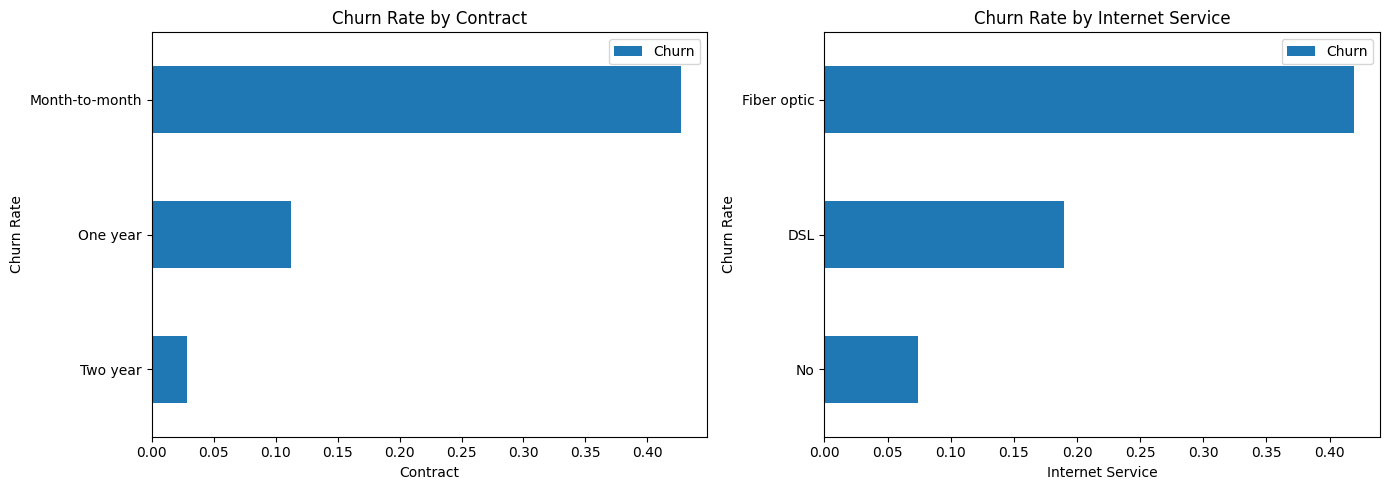

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Churn rate by contract

contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean()).sort_values()
contract_churn.plot(kind = 'barh', ax = axes[0])
axes[0].set_title('Churn Rate by Contract')
axes[0].set_xlabel('Contract')
axes[0].set_ylabel('Churn Rate')
axes[0].legend()

# Churn rate by intenet Service
internew_churn = df.groupby('InternetService')['Churn'].apply(lambda x: (x=='Yes').mean()).sort_values()
internew_churn.plot(kind = 'barh', ax = axes[1])
axes[1].set_title('Churn Rate by Internet Service')
axes[1].set_xlabel('Internet Service')
axes[1].set_ylabel('Churn Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Amount?? --  you can do it for yourseld

In [ ]:
pay_churn = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x=='Yes').mean()).sort_values(ascending=False)
print("Churn Rate by the Pyament method")
pay_churn.round(3)

Churn Rate by the Pyament method


,Churn
PaymentMethod,
Electronic check,0.453
Mailed check,0.191
Bank transfer (automatic),0.167
Credit card (automatic),0.152


# Clean the data and prep for the Modelling

In [ ]:
df['Churn']

,Churn
0,No
1,No
2,Yes
3,No
4,Yes
...,...
7038,No
7039,No
7040,No
7041,Yes


In [ ]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

# Encoding the Churn Column

df['Churn'] = (df['Churn']=='Yes').astype(int)

df = df.drop('customerID', axis = 1)

num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

# Correcting cat_cols to exclude 'Churn' as it's the target variable
cat_cols = [c for c in df.columns if c not in num_cols and c != 'Churn']
'''
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn']

      '''

print(len(num_cols))

print(len(cat_cols))

4
15


In [ ]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
])

# Step 6: Train/test split (stratified — keeps churn ratio same in both sets)
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 19)
(1409, 19)
(5634,)
(1409,)


# Lets train base line models

- Logistic Regression
- Decision tree ( Rule based )
- Randome Forest

-- Class_weights = 'Balanced'

In [ ]:
y_train

,Churn
3738,0
3151,0
4860,0
3867,0
3810,0
...,...
6303,0
6227,1
4673,1
2710,0


In [ ]:
preprocesser

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod', 'Churn',
                                  'Churn'])])

In [ ]:
import time
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced',
                                              random_state = 42,
                                              max_iter = 1000),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced',
                                            max_depth = 5,
                                            random_state= 42),
    'Random Forest': RandomForestClassifier(class_weight='balanced',
                                            n_estimators = 100,
                                            random_state= 42,
                                            n_jobs = -1)
}


results = []

trained_pipes = {}

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    elapsed = time.time() - t0

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'CV AUC (mean)': cv_auc.mean(),
        'CV AUC (std)': cv_auc.std(),
        'Train Time (s)': round(elapsed, 3),
    })
    trained_pipes[name] = pipe

comparision_df = pd.DataFrame(results)


comparision_df.round(4).to_string()



'                 Model  Accuracy  Precision  Recall      F1  ROC-AUC  CV AUC (mean)  CV AUC (std)  Train Time (s)\n0  Logistic Regression    0.7381     0.5043  0.7834  0.6136   0.8416         0.8454        0.0141           0.094\n1        Decision Tree    0.7544     0.5260  0.7567  0.6206   0.8318         0.8214        0.0176           0.087\n2        Random Forest    0.7807     0.6102  0.4813  0.5381   0.8194         0.8239        0.0118           0.794'

In [ ]:
print("=" * 80)
print("Baseline Model Comparision Table")
print("=" * 80)

print(comparision_df.round(4).to_string(index = False))

Baseline Model Comparision Table
              Model  Accuracy  Precision  Recall     F1  ROC-AUC  CV AUC (mean)  CV AUC (std)  Train Time (s)
Logistic Regression    0.7381     0.5043  0.7834 0.6136   0.8416         0.8454        0.0141           0.094
      Decision Tree    0.7544     0.5260  0.7567 0.6206   0.8318         0.8214        0.0176           0.087
      Random Forest    0.7807     0.6102  0.4813 0.5381   0.8194         0.8239        0.0118           0.794


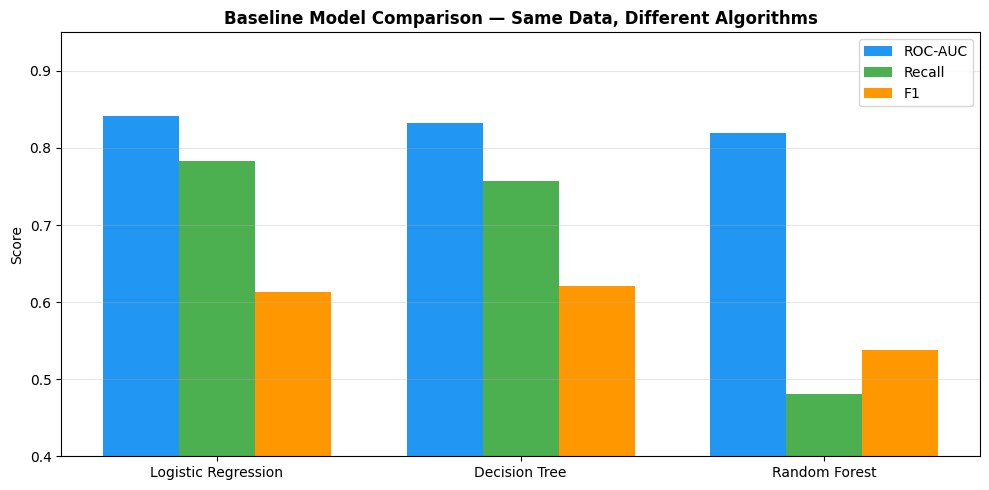

In [ ]:
fix, ax = plt.subplots(figsize = (10, 5))
metrics_to_plot = ['ROC-AUC', 'Recall', 'F1']

x = np.arange(len(comparision_df))
width = 0.25
colors = ['#2196F3', '#4CAF50', '#FF9800']


for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, comparision_df[metric], width, label=metric, color=colors[i])

ax.set_xticks(x + width)
ax.set_xticklabels(comparision_df['Model'])
ax.set_ylim(0.4, 0.95)
ax.set_ylabel('Score')
ax.set_title('Baseline Model Comparison — Same Data, Different Algorithms', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Grid Search CV

In [ ]:
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [5, 10, 15, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 5, 10]
}


rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced',
                                     random_state=42,
                                     n_jobs = -1))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


grid_search = GridSearchCV(rf_pipeline,
                           param_grid,
                           cv=cv,
                           scoring='roc_auc',
                           n_jobs=-1,
                           verbose = 1)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['SeniorCitizen',
                                                                          'tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['gender',
                                                                          'Partner',
                                                                          'Dependents',
                                                                          'PhoneService',
                                                                          'MultipleLine...
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaperlessBilling',
                                                                          'PaymentMethod'])])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, 15, None],
                         'model__min_samples_leaf': [1, 5, 10],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [50, 100, 200]},
             scoring='roc_auc', verbose=1)

In [ ]:
print("Best Parameters:", grid_search.best_params_)
print("Best ROC-AUC Score:", grid_search.best_score_)

Best Parameters: {'model__max_depth': None, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best ROC-AUC Score: 0.8475215984460913


In [ ]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_model__min_samples_leaf,param_model__min_samples_split,param_model__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.776714,0.226622,0.113037,0.034421,5,1,2,50,"{'model__max_depth': 5, 'model__min_samples_le...",0.838558,0.833982,0.839221,0.861959,0.850311,0.844806,0.010119,42
1,1.015790,0.154390,0.157346,0.014583,5,1,2,100,"{'model__max_depth': 5, 'model__min_samples_le...",0.838477,0.833475,0.839216,0.860895,0.849947,0.844402,0.009840,54
2,1.721023,0.213476,0.158683,0.062905,5,1,2,200,"{'model__max_depth': 5, 'model__min_samples_le...",0.839487,0.833045,0.840040,0.860586,0.851476,0.844927,0.009826,40
3,0.396914,0.050596,0.084911,0.034898,5,1,5,50,"{'model__max_depth': 5, 'model__min_samples_le...",0.838675,0.833739,0.838974,0.862014,0.850572,0.844795,0.010232,43
4,1.251141,0.216995,0.135958,0.029689,5,1,5,100,"{'model__max_depth': 5, 'model__min_samples_le...",0.838619,0.833362,0.838869,0.860943,0.850024,0.844363,0.009911,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,1.410155,0.256540,0.162424,0.070387,None,10,5,100,"{'model__max_depth': None, 'model__min_samples...",0.842502,0.832350,0.844425,0.857526,0.859073,0.847175,0.009979,13
104,3.049229,0.603879,0.239926,0.057938,None,10,5,200,"{'model__max_depth': None, 'model__min_samples...",0.842038,0.833069,0.845879,0.856803,0.859819,0.847522,0.009788,1
105,0.690205,0.083399,0.141098,0.042520,None,10,10,50,"{'model__max_depth': None, 'model__min_samples...",0.839150,0.832124,0.843112,0.858213,0.857783,0.846076,0.010352,25
106,1.464103,0.291614,0.211012,0.045904,None,10,10,100,"{'model__max_depth': None, 'model__min_samples...",0.842502,0.832350,0.844425,0.857526,0.859073,0.847175,0.009979,13


# train model for best paramaters

In [ ]:
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
y_prob_tuned = best_rf.predict_proba(X_test)[:, 1]


print('TUNED Random Forest — Test Set Performance:')
print(f'  ROC-AUC:   {roc_auc_score(y_test, y_prob_tuned):.4f}')
print(f'  Recall:    {recall_score(y_test, y_pred_tuned):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred_tuned):.4f}')
print(f'  F1:        {f1_score(y_test, y_pred_tuned):.4f}')
print(f'  Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}')


TUNED Random Forest — Test Set Performance:
  ROC-AUC:   0.8429
  Recall:    0.7674
  Precision: 0.5354
  F1:        0.6308
  Accuracy:  0.7615


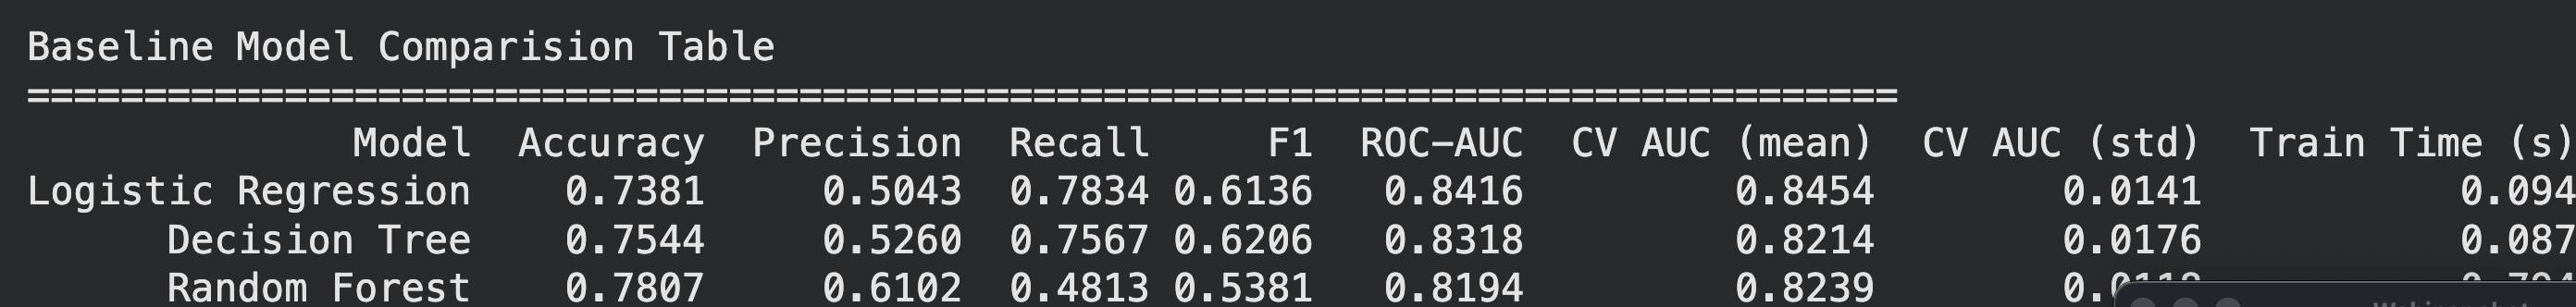

# Confusion Matrix

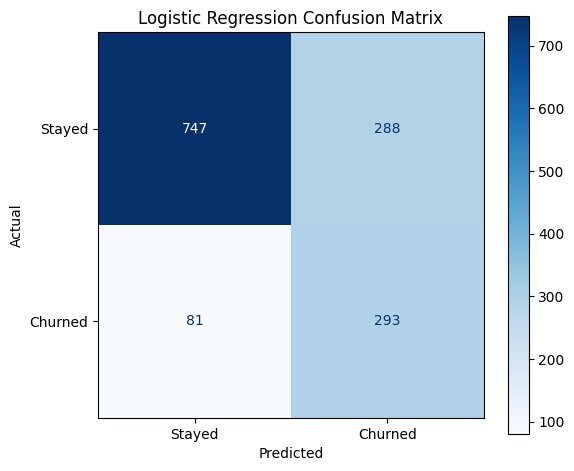

In [ ]:
winner = trained_pipes['Logistic Regression']
y_pred_winner = winner.predict(X_test)

fix, ax = plt.subplots(figsize = (6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_winner),
                       display_labels = ['Stayed', 'Churned']).plot(ax=ax, cmap = "Blues")
ax.set_title("Logistic Regression Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_winner))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



# Save adn Load the model

In [ ]:
import joblib

In [ ]:
joblib.dump(trained_pipes['Logistic Regression'],
            "churn_logred_pipeline.joblib")

joblib.dump(best_rf, 'churn_rf_tuned_pipeline.joblib')


print("Saved both models")

Saved both models


# Load the models

In [ ]:
loaded_lr = joblib.load("/content/churn_logred_pipeline.joblib")
loaded_pred = loaded_lr.predict(X_test)

loaded_rf = joblib.load("/content/churn_rf_tuned_pipeline.joblib")
loaded_pred_rf = loaded_rf.predict(X_test)

In [ ]:
sample = X_test.sample(1)
print(f"\nLogistic Regression Prediction: {loaded_lr.predict(sample)[0]}")
print(f"Random Forest Prediction: {loaded_rf.predict(sample)[0]}")


Logistic Regression Prediction: 1
Random Forest Prediction: 1
